<a href="https://colab.research.google.com/github/Anzonfire/Machine-Learning/blob/main/expno%202/SCENARIO_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-944/2573864285.py:12: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bottle.csv")


Linear Regression Results
MSE: 6.266115569116481
RMSE: 2.5032210388050995
R2 Score: 0.646907020740291


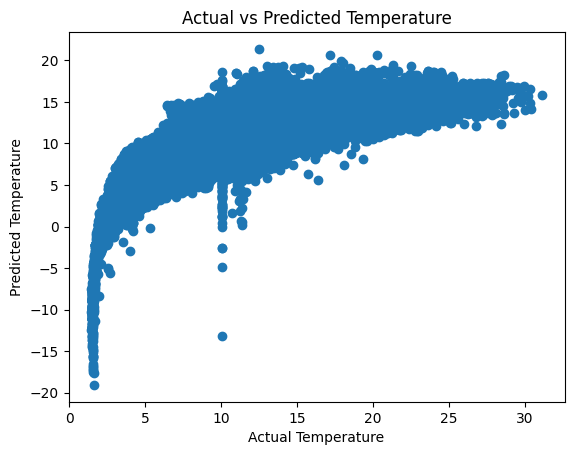

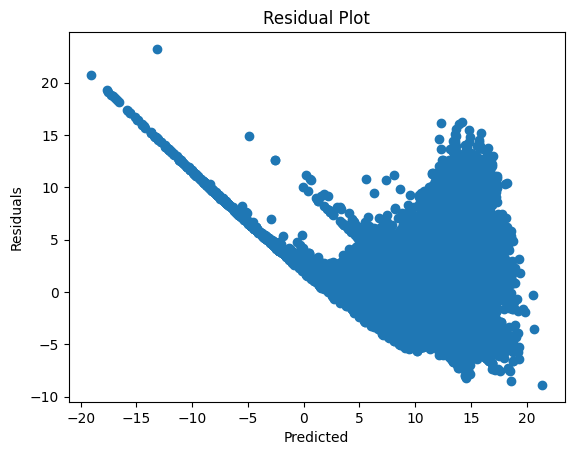


Ridge R2: 0.6469070213032113
Lasso R2: 0.6419380977359064


In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
# Load Dataset
df = pd.read_csv("bottle.csv")
features = ['Depthm', 'Salnty', 'O2ml_L']
target = 'T_degC'

df = df[features + [target]]


df.fillna(df.median(), inplace=True)

X = df[features]
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()


residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("\nRidge R2:", r2_score(y_test, ridge_pred))


lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))